🌊 Water Demand Forecasting — LSTM + MPC
> **Project:** Water Demand Forecasting for Tangier (2026–2035)  
> **Model:** Long Short-Term Memory (LSTM) + Model Predictive Control (MPC)  
> **Data:** `tangier_synthetic_water_model_with_supply_FIXED_STORAGE_2000_2035.csv`

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from scipy.optimize import linprog


I0000 00:00:1774556537.091276   11345 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774556537.125482   11345 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774556538.014085   11345 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


---
##  2. Data Loading & Preprocessing
### 2.1 Dataset Loading

In [2]:
df = pd.read_csv("../data/tangier_synthetic_water_model_with_supply_FIXED_STORAGE_2000_2035.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df["storage_baseline_mcm"] = df["storage_baseline_mcm"] / 2

df.head()


,date,year,month,population,rainfall_mm,temperature_c,evaporation_mcm,total_demand_mcm,storage_baseline_mcm,storage_rain_minus3_mcm,storage_rain_minus5_mcm,stress_baseline,stress_rain_minus3,stress_rain_minus5,delta_storage,supply_mcm,storage_original_mcm,storage_reconstructed_mcm
0,2000-01-01,2000,1,661516,103.05,17.91,0.358,20.342,70.000000,180.000,180.000,0.113,0.113,0.113,0.000,20.342,180.000,140.000000
1,2000-02-01,2000,2,663405,84.24,19.72,0.394,28.142,66.242062,180.291,179.858,0.156,0.156,0.156,0.940,29.082,180.940,132.484123
2,2000-03-01,2000,3,665294,87.50,23.85,0.477,30.467,58.750657,168.914,168.127,0.179,0.180,0.181,-10.846,19.621,170.094,117.501315
3,2000-04-01,2000,4,667184,69.41,23.58,0.472,33.043,45.829306,155.795,154.641,0.210,0.212,0.214,-12.568,20.475,157.526,91.658613
4,2000-05-01,2000,5,669073,20.49,22.82,0.456,31.432,37.617123,136.418,134.973,0.227,0.230,0.233,-18.939,12.493,138.587,75.234245


### 2.2 Feature Engineering

In [3]:
df = df.copy()

# Normalize climate variables for weighting
temp_norm = (df["temperature_c"] - df["temperature_c"].min()) / (
    df["temperature_c"].max() - df["temperature_c"].min()
)

rain_norm = (df["rainfall_mm"] - df["rainfall_mm"].min()) / (
    df["rainfall_mm"].max() - df["rainfall_mm"].min()
)

pop_norm = (df["population"] - df["population"].min()) / (
    df["population"].max() - df["population"].min()
)

# Raw sector scores
# Domestic increases with population and slightly with temperature
dom_score = 0.35 + 0.20 * pop_norm + 0.10 * temp_norm

# Agriculture increases when rainfall is low and temperature is high
agri_score = 0.30 + 0.25 * (1 - rain_norm) + 0.15 * temp_norm

# Industry is more stable, slight dependence on population/economic growth proxy
ind_score = 0.15 + 0.10 * pop_norm

# Sum scores
score_sum = dom_score + agri_score + ind_score

# Convert to weights
df["domestic_weight"] = dom_score / score_sum
df["agriculture_weight"] = agri_score / score_sum
df["industry_weight"] = ind_score / score_sum

# Sector demand
df["domestic_demand"] = df["total_demand_mcm"] * df["domestic_weight"]
df["agriculture_demand"] = df["total_demand_mcm"] * df["agriculture_weight"]
df["industry_demand"] = df["total_demand_mcm"] * df["industry_weight"]

# Check
df["sector_sum"] = (
    df["domestic_demand"] +
    df["agriculture_demand"] +
    df["industry_demand"]
)

print(df[[
    "date", "total_demand_mcm",
    "domestic_demand", "agriculture_demand", "industry_demand",
    "sector_sum"
]].head())

        date  total_demand_mcm  domestic_demand  agriculture_demand  \
0 2000-01-01            20.342         8.506107            8.610575   
1 2000-02-01            28.142        11.294614           12.685384   
2 2000-03-01            30.467        12.306533           13.900191   
3 2000-04-01            33.043        12.890018           15.671771   
4 2000-05-01            31.432        11.204500           16.287079   

   industry_demand  sector_sum  
0         3.225318      20.342  
1         4.162002      28.142  
2         4.260276      30.467  
3         4.481211      33.043  
4         3.940421      31.432  


### 2.3 Feature & Target Definition

In [4]:
# =========================
# Define features and targets (CLEAN)
# =========================

X_cols = [
    "population",
    "rainfall_mm",
    "temperature_c",
    "evaporation_mcm",
    "total_demand_mcm",
    "storage_baseline_mcm",
    "supply_mcm",
]

y_cols = [
    "domestic_demand",
    "agriculture_demand",
    "industry_demand",
    "supply_mcm",
    "storage_baseline_mcm"
]

---
##  3. Data Splitting & Normalization
### 3.1 Train / Validation / Test Split

In [6]:
train_end = pd.Timestamp("2021-12-01")
val_end   = pd.Timestamp("2025-12-01")

train_df = df[df["date"] <= train_end].copy()
val_df   = df[(df["date"] > train_end) & (df["date"] <= val_end)].copy()
test_df  = df[df["date"] > val_end].copy()

print("Rows:", len(df), "Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

Rows: 432 Train: 264 Val: 48 Test: 120


### 3.2 Normalization (MinMaxScaler)

In [7]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train = X_scaler.fit_transform(train_df[X_cols])
y_train = y_scaler.fit_transform(train_df[y_cols])

X_val = X_scaler.transform(val_df[X_cols])
y_val = y_scaler.transform(val_df[y_cols])

X_test = X_scaler.transform(test_df[X_cols])
y_test = y_scaler.transform(test_df[y_cols])

### 3.3 Time Sequence Creation

In [8]:
def make_sequences(X, y, seq_length=12):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i : i + seq_length])
        y_seq.append(y[i + seq_length])  # predict next month
    return np.array(X_seq), np.array(y_seq)

seq_length = 18

X_train_seq, y_train_seq = make_sequences(X_train, y_train, seq_length)
X_val_seq, y_val_seq = make_sequences(X_val, y_val, seq_length)
X_test_seq, y_test_seq = make_sequences(X_test, y_test, seq_length)

print("Train shapes:", X_train_seq.shape, y_train_seq.shape)
print("Val shapes:", X_val_seq.shape, y_val_seq.shape)
print("Test shapes:", X_test_seq.shape, y_test_seq.shape)

Train shapes: (246, 18, 7) (246, 5)
Val shapes: (30, 18, 7) (30, 5)
Test shapes: (102, 18, 7) (102, 5)


### 3.4 Date Alignment

In [9]:
def aligned_dates(sub_df, seq_length=12):
    return sub_df["date"].iloc[seq_length:].reset_index(drop=True)

train_dates = aligned_dates(train_df, seq_length)
val_dates = aligned_dates(val_df, seq_length)
test_dates = aligned_dates(test_df, seq_length)

---
##  4. LSTM Model
### 4.1 Model Architecture

In [12]:
# =========================
# Build LSTM
# =========================

tf.random.set_seed(42)

model = keras.Sequential([

    layers.Input(shape=(seq_length, X_train_seq.shape[2])),

    layers.LSTM(64, return_sequences=False),

    layers.Dropout(0.2),

    layers.Dense(16, activation="relu"),

    layers.Dense(5)  # domestic + agriculture + industry + supply + storage
])

model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,557 (76.39 KB)

 Trainable params: 19,557 (76.39 KB)

 Non-trainable params: 0 (0.00 B)

### 4.2 Model Training
> Uses **EarlyStopping** and **ModelCheckpoint** to prevent overfitting.

In [13]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    ),

    keras.callbacks.ModelCheckpoint(
        "best_lstm_sector_supply_storage.keras",
        monitor="val_loss",
        save_best_only=True
    )

]

history = model.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(X_val_seq, y_val_seq),

    epochs=200,

    batch_size=16,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0551 - mae: 0.2715 - val_loss: 0.0406 - val_mae: 0.2470
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0335 - mae: 0.2185 - val_loss: 0.0358 - val_mae: 0.2284
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0271 - mae: 0.1968 - val_loss: 0.0311 - val_mae: 0.2163
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0251 - mae: 0.1859 - val_loss: 0.0250 - val_mae: 0.1928
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0189 - mae: 0.1604 - val_loss: 0.0169 - val_mae: 0.1576
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0127 - mae: 0.1303 - val_loss: 0.0076 - val_mae: 0.1019
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0073 - mae: 0.0965 - val_loss: 0.0042 - val_mae: 0.0762
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0063 - mae: 0.0879 - val_loss: 0.0036 - val_mae: 0.0694
Epoch 9/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.00

---
##  5. Evaluation — Validation Phase (2022–2025)
### 5.1 Predictions on Validation Set

In [14]:
y_val_pred_scaled = model.predict(X_val_seq)
y_val_pred = y_scaler.inverse_transform(y_val_pred_scaled)

domestic_val_pred = y_val_pred[:, 0]
agriculture_val_pred = y_val_pred[:, 1]
industry_val_pred = y_val_pred[:, 2]
supply_val_pred = y_val_pred[:, 3]
storage_val_pred = y_val_pred[:, 4]

storage_val_pred = np.clip(storage_val_pred, 20, 175)

domestic_val_true = val_df["domestic_demand"].iloc[seq_length:].values
agriculture_val_true = val_df["agriculture_demand"].iloc[seq_length:].values
industry_val_true = val_df["industry_demand"].iloc[seq_length:].values
supply_val_true = val_df["supply_mcm"].iloc[seq_length:].values
storage_val_true = val_df["storage_baseline_mcm"].iloc[seq_length:].values

demand_val_pred = domestic_val_pred + agriculture_val_pred + industry_val_pred
demand_val_true = val_df["total_demand_mcm"].iloc[seq_length:].values

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


### 5.2 Validation Metrics (MAE / RMSE)

In [15]:
print("=== VALIDATION METRICS (2022–2025) ===")

print("Domestic Demand MAE:", mean_absolute_error(domestic_val_true, domestic_val_pred))
print("Domestic Demand RMSE:", np.sqrt(mean_squared_error(domestic_val_true, domestic_val_pred)))

print("Agricultural Demand MAE:", mean_absolute_error(agriculture_val_true, agriculture_val_pred))
print("Agricultural Demand RMSE:", np.sqrt(mean_squared_error(agriculture_val_true, agriculture_val_pred)))

print("Industrial Demand MAE:", mean_absolute_error(industry_val_true, industry_val_pred))
print("Industrial Demand RMSE:", np.sqrt(mean_squared_error(industry_val_true, industry_val_pred)))

print("Total Demand MAE:", mean_absolute_error(demand_val_true, demand_val_pred))
print("Total Demand RMSE:", np.sqrt(mean_squared_error(demand_val_true, demand_val_pred)))

print("Supply MAE:", mean_absolute_error(supply_val_true, supply_val_pred))
print("Supply RMSE:", np.sqrt(mean_squared_error(supply_val_true, supply_val_pred)))

print("Storage MAE:", mean_absolute_error(storage_val_true, storage_val_pred))
print("Storage RMSE:", np.sqrt(mean_squared_error(storage_val_true, storage_val_pred)))

=== VALIDATION METRICS (2022–2025) ===
Domestic Demand MAE: 0.5437773245796833
Domestic Demand RMSE: 0.709166525931357
Agricultural Demand MAE: 0.6219976083626723
Agricultural Demand RMSE: 0.766753392434126
Industrial Demand MAE: 0.24258701767918903
Industrial Demand RMSE: 0.3080422558387637
Total Demand MAE: 1.1244372060139975
Total Demand RMSE: 1.4430814137179282
Supply MAE: 1.9226869758605958
Supply RMSE: 2.2727500741384867
Storage MAE: 3.9592250675465466
Storage RMSE: 4.498823949041492


---
##  6. Forecast — Test Phase (2026–2035)
### 6.1 Predictions on Forecast Horizon

In [16]:
y_test_pred_scaled = model.predict(X_test_seq)
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)

domestic_pred = y_test_pred[:, 0]
agriculture_pred = y_test_pred[:, 1]
industry_pred = y_test_pred[:, 2]
supply_pred = y_test_pred[:, 3]
storage_pred = y_test_pred[:, 4]

storage_pred = np.clip(storage_pred, 20, 175)

domestic_true = test_df["domestic_demand"].iloc[seq_length:].values
agriculture_true = test_df["agriculture_demand"].iloc[seq_length:].values
industry_true = test_df["industry_demand"].iloc[seq_length:].values
supply_true = test_df["supply_mcm"].iloc[seq_length:].values
storage_true = test_df["storage_baseline_mcm"].iloc[seq_length:].values

demand_pred = domestic_pred + agriculture_pred + industry_pred
demand_true = test_df["total_demand_mcm"].iloc[seq_length:].values

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


### 6.2 Test Metrics (MAE / RMSE)

In [17]:
print("=== TEST METRICS (2026–2035) ===")

print("Domestic Demand MAE:", mean_absolute_error(domestic_true, domestic_pred))
print("Domestic Demand RMSE:", np.sqrt(mean_squared_error(domestic_true, domestic_pred)))

print("Agricultural Demand MAE:", mean_absolute_error(agriculture_true, agriculture_pred))
print("Agricultural Demand RMSE:", np.sqrt(mean_squared_error(agriculture_true, agriculture_pred)))

print("Industrial Demand MAE:", mean_absolute_error(industry_true, industry_pred))
print("Industrial Demand RMSE:", np.sqrt(mean_squared_error(industry_true, industry_pred)))

print("Total Demand MAE:", mean_absolute_error(demand_true, demand_pred))
print("Total Demand RMSE:", np.sqrt(mean_squared_error(demand_true, demand_pred)))

print("Supply MAE:", mean_absolute_error(supply_true, supply_pred))
print("Supply RMSE:", np.sqrt(mean_squared_error(supply_true, supply_pred)))

print("Storage MAE:", mean_absolute_error(storage_true, storage_pred))
print("Storage RMSE:", np.sqrt(mean_squared_error(storage_true, storage_pred)))

=== TEST METRICS (2026–2035) ===
Domestic Demand MAE: 0.7339370673195693
Domestic Demand RMSE: 0.9335519243092991
Agricultural Demand MAE: 0.8695520201582514
Agricultural Demand RMSE: 1.0198294428884858
Industrial Demand MAE: 0.32547591141031684
Industrial Demand RMSE: 0.4143133984513194
Total Demand MAE: 1.5579334297928156
Total Demand RMSE: 1.8823389750176907
Supply MAE: 2.4679448830099666
Supply RMSE: 2.9250281723749185
Storage MAE: 4.209157103365554
Storage RMSE: 5.356705647498512


---
##  7. Visualizations
### 7.1 Loss Curve — Training vs Validation

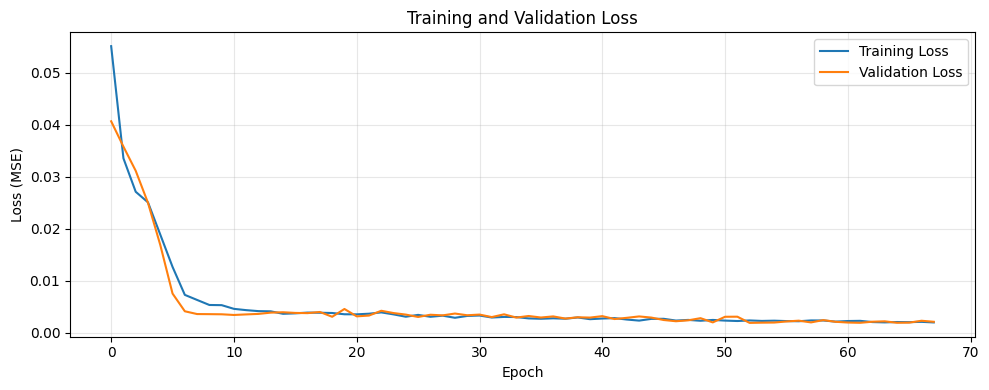

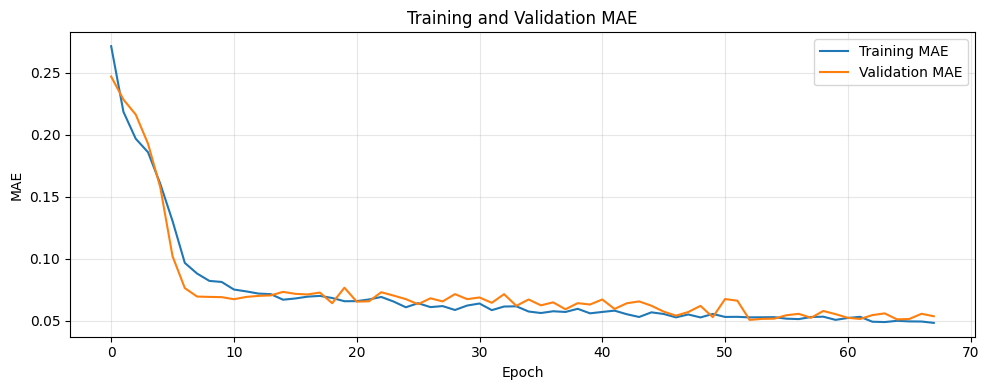

In [18]:
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.title("Training and Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Total Demand — Validation
## Total Demand

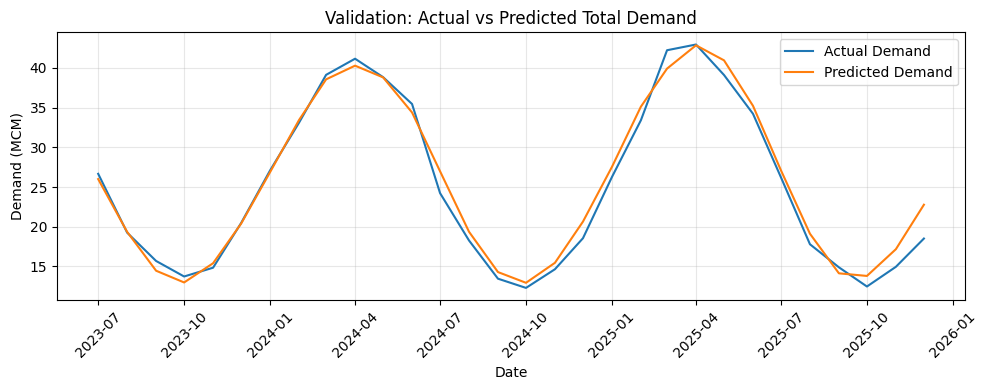

In [19]:
plt.figure(figsize=(10,4))
plt.plot(val_dates, demand_val_true, label="Actual Demand")
plt.plot(val_dates, demand_val_pred, label="Predicted Demand")
plt.title("Validation: Actual vs Predicted Total Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MCM)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Supply

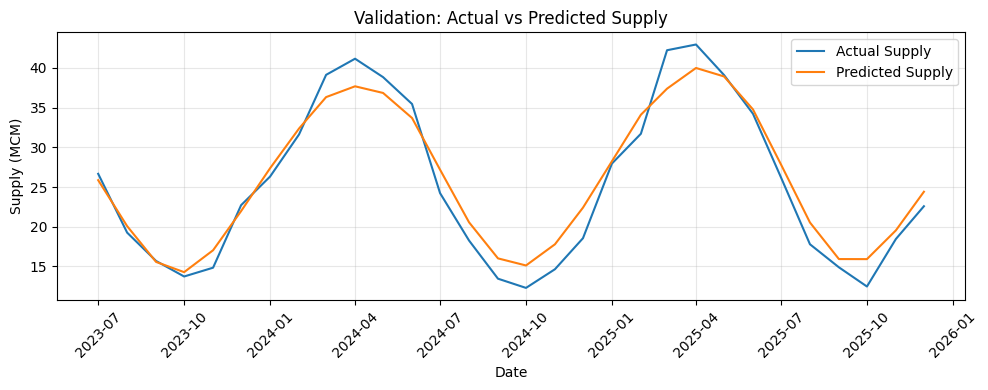

In [20]:
plt.figure(figsize=(10,4))
plt.plot(val_dates, supply_val_true, label="Actual Supply")
plt.plot(val_dates, supply_val_pred, label="Predicted Supply")
plt.title("Validation: Actual vs Predicted Supply")
plt.xlabel("Date")
plt.ylabel("Supply (MCM)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Storage

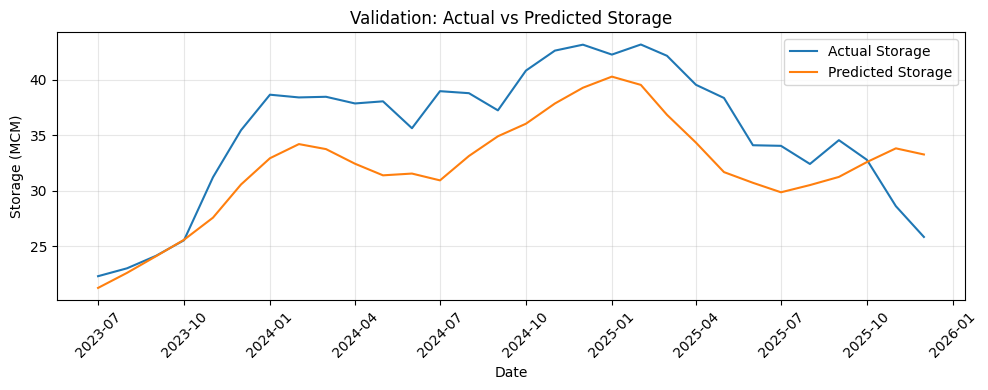

In [21]:
plt.figure(figsize=(10,4))
plt.plot(val_dates, storage_val_true, label="Actual Storage")
plt.plot(val_dates, storage_val_pred, label="Predicted Storage")
plt.title("Validation: Actual vs Predicted Storage")
plt.xlabel("Date")
plt.ylabel("Storage (MCM)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7.3 Total Demand — Test / Forecast
## Total Demand

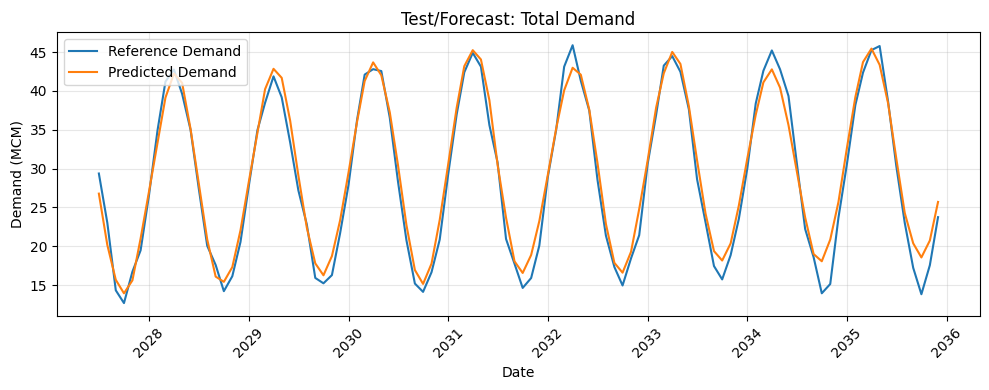

In [22]:
plt.figure(figsize=(10,4))
plt.plot(test_dates, demand_true, label="Reference Demand")
plt.plot(test_dates, demand_pred, label="Predicted Demand")
plt.title("Test/Forecast: Total Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MCM)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Supply

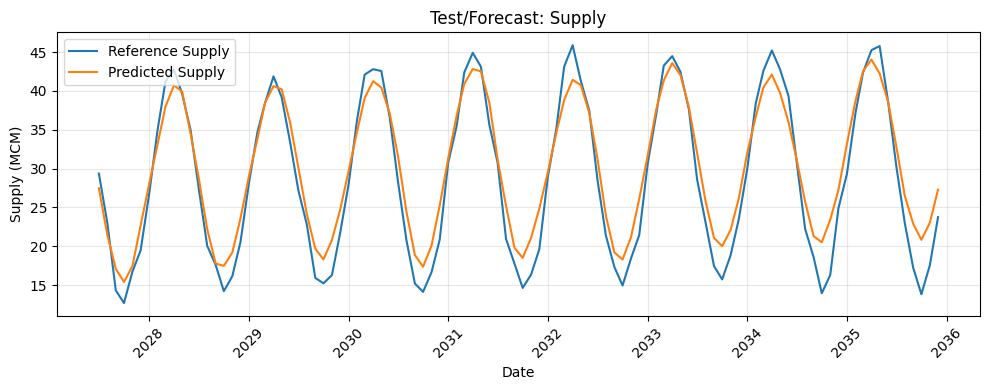

In [23]:
plt.figure(figsize=(10,4))
plt.plot(test_dates, supply_true, label="Reference Supply")
plt.plot(test_dates, supply_pred, label="Predicted Supply")
plt.title("Test/Forecast: Supply")
plt.xlabel("Date")
plt.ylabel("Supply (MCM)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Storage

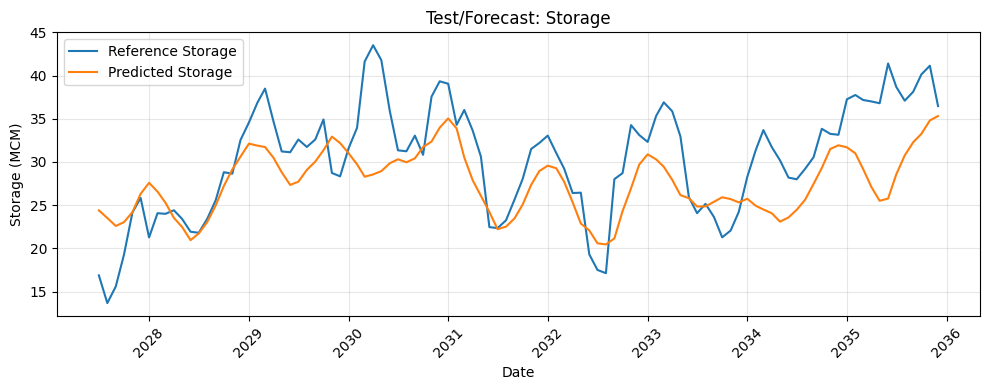

In [24]:
plt.figure(figsize=(10,4))
plt.plot(test_dates, storage_true, label="Reference Storage")
plt.plot(test_dates, storage_pred, label="Predicted Storage")
plt.title("Test/Forecast: Storage")
plt.xlabel("Date")
plt.ylabel("Storage (MCM)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7.4 Scatter Plot: Actual vs Predicted (Storage)

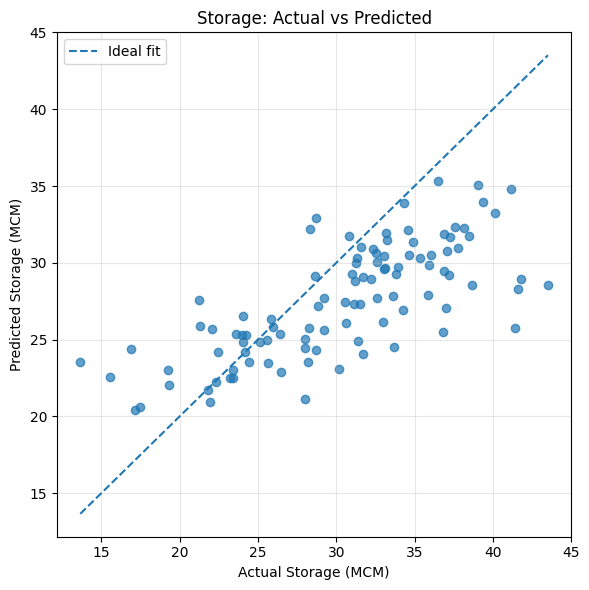

In [25]:
# =========================
# Scatter plot: Actual vs Predicted
# =========================

plt.figure(figsize=(6,6))
plt.scatter(storage_true, storage_pred, alpha=0.7)

min_val = min(storage_true.min(), storage_pred.min())
max_val = max(storage_true.max(), storage_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "--", label="Ideal fit")
plt.xlabel("Actual Storage (MCM)")
plt.ylabel("Predicted Storage (MCM)")
plt.title("Storage: Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.5 Residual Analysis (Storage)

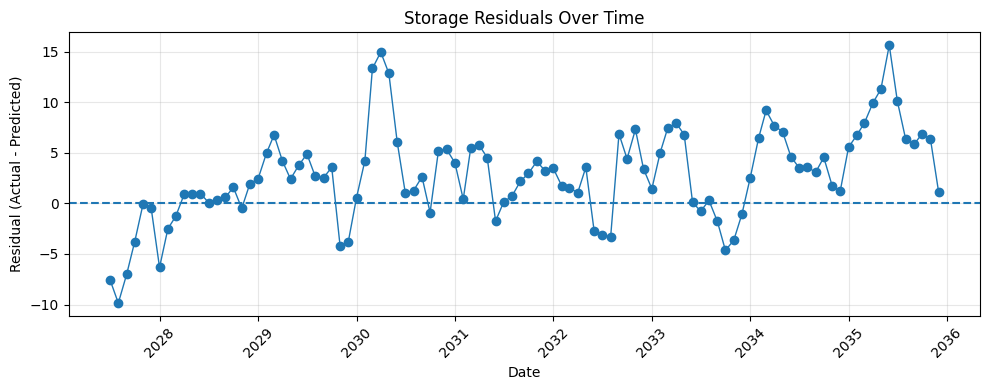

In [26]:
# =========================
# Residual plot
# =========================

storage_residuals = storage_true - storage_pred

plt.figure(figsize=(10,4))
plt.plot(test_dates, storage_residuals, marker="o", linewidth=1)
plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Storage Residuals Over Time")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7.6 Sector Demands — Validation
> Individual comparison: Domestic | Agricultural | Industrial

In [27]:
COLORS = {
    "domestic": "#4C72B0",
    "agriculture": "#DD8452",
    "industry": "#55A868",
}

## Domestic

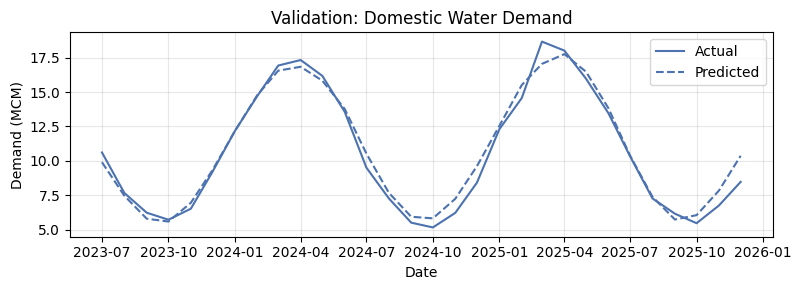

In [28]:
plt.figure(figsize=(8,3))
plt.plot(val_dates, domestic_val_true, color=COLORS["domestic"], label="Actual")
plt.plot(val_dates, domestic_val_pred, "--", color=COLORS["domestic"], label="Predicted")
plt.title("Validation: Domestic Water Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MCM)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Agriculture

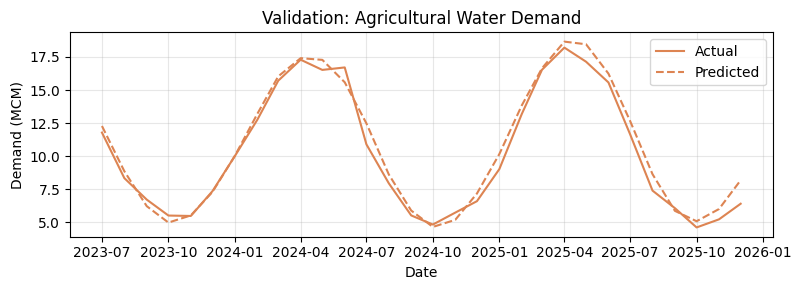

In [29]:
plt.figure(figsize=(8,3))
plt.plot(val_dates, agriculture_val_true, color=COLORS["agriculture"], label="Actual")
plt.plot(val_dates, agriculture_val_pred, "--", color=COLORS["agriculture"], label="Predicted")
plt.title("Validation: Agricultural Water Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MCM)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Industry

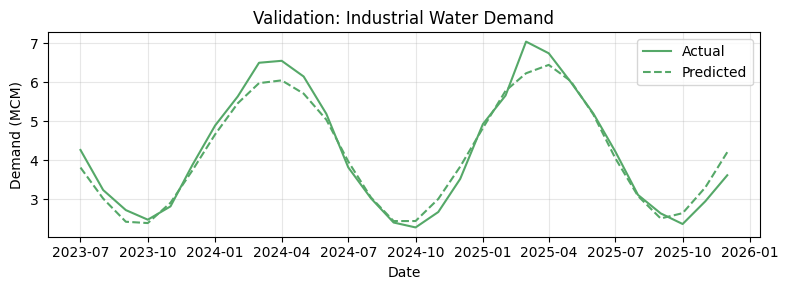

In [30]:
plt.figure(figsize=(8,3))
plt.plot(val_dates, industry_val_true, color=COLORS["industry"], label="Actual")
plt.plot(val_dates, industry_val_pred, "--", color=COLORS["industry"], label="Predicted")
plt.title("Validation: Industrial Water Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MCM)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.7 Sector Demands — Test / Forecast
> Individual comparison: Domestic | Agricultural | Industrial

In [31]:
COLORS = {
    "domestic": "#4C72B0",
    "agriculture": "#DD8452",
    "industry": "#55A868",
}

## Domestic

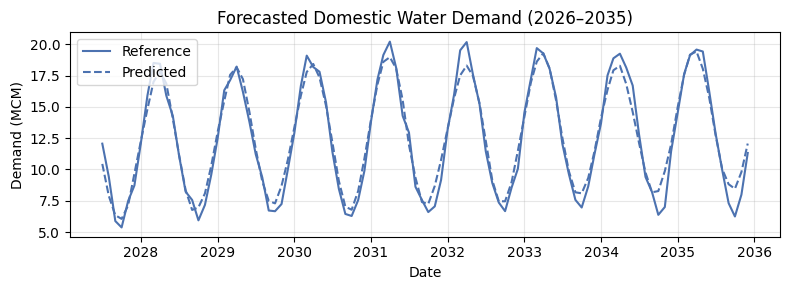

In [32]:
plt.figure(figsize=(8,3))
plt.plot(test_dates, domestic_true, color=COLORS["domestic"], label="Reference")
plt.plot(test_dates, domestic_pred, "--", color=COLORS["domestic"], label="Predicted")
plt.title("Forecasted Domestic Water Demand (2026–2035)")
plt.xlabel("Date")
plt.ylabel("Demand (MCM)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Agricultural

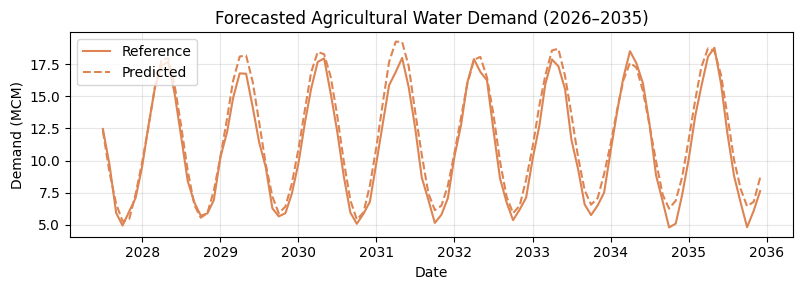

In [33]:
plt.figure(figsize=(8,3))
plt.plot(test_dates, agriculture_true, color=COLORS["agriculture"], label="Reference")
plt.plot(test_dates, agriculture_pred, "--", color=COLORS["agriculture"], label="Predicted")
plt.title("Forecasted Agricultural Water Demand (2026–2035)")
plt.xlabel("Date")
plt.ylabel("Demand (MCM)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Industrial

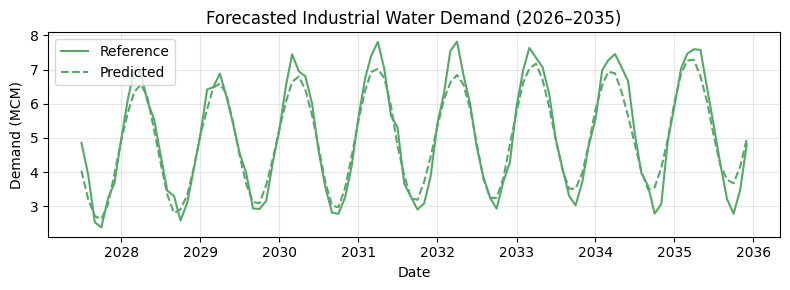

In [34]:
plt.figure(figsize=(8,3))
plt.plot(test_dates, industry_true, color=COLORS["industry"], label="Reference")
plt.plot(test_dates, industry_pred, "--", color=COLORS["industry"], label="Predicted")
plt.title("Forecasted Industrial Water Demand (2026–2035)")
plt.xlabel("Date")
plt.ylabel("Demand (MCM)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.8 Demand Breakdown (Stacked Area Chart)

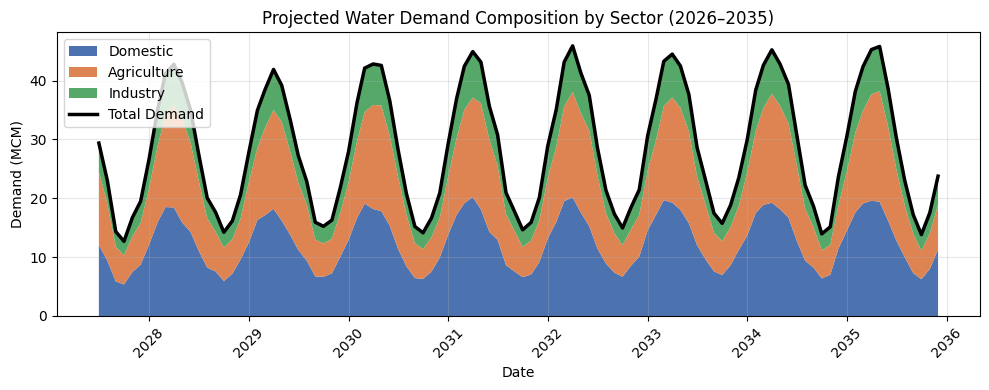

In [35]:
plt.figure(figsize=(10,4))
colors = ["#4C72B0", "#DD8452", "#55A868"] 

plt.stackplot(
    test_dates,
    domestic_true,
    agriculture_true,
    industry_true,
    labels=["Domestic", "Agriculture", "Industry"],
    colors=colors
)

plt.plot(test_dates, demand_true, color="black", linewidth=2.5, label="Total Demand")
plt.grid(alpha=0.3)
plt.title("Projected Water Demand Composition by Sector (2026–2035)")
plt.xlabel("Date")
plt.ylabel("Demand (MCM)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
##  8. Water Stress Analysis (2026–2035)
### 8.1 Stress Index Calculation

        date  demand_pred_mcm  supply_pred_mcm  storage_pred_mcm  stress_pred  \
0 2027-07-01        26.782734        27.483881         24.394938     1.025778   
1 2027-08-01        20.169548        21.475269         23.511753     0.988630   
2 2027-09-01        15.682903        17.096127         22.588537     0.965617   
3 2027-10-01        13.942003        15.406227         23.029953     0.952588   
4 2027-11-01        15.615792        17.445427         24.187654     0.942234   

   demand_true_mcm  supply_true_mcm  storage_true_mcm  stress_true  
0           29.373           29.373         16.868368          1.0  
1           23.022           23.022         13.659200          1.0  
2           14.330           14.330         15.582067          1.0  
3           12.684           12.684         19.260951          1.0  
4           16.733           16.733         24.150424          1.0  


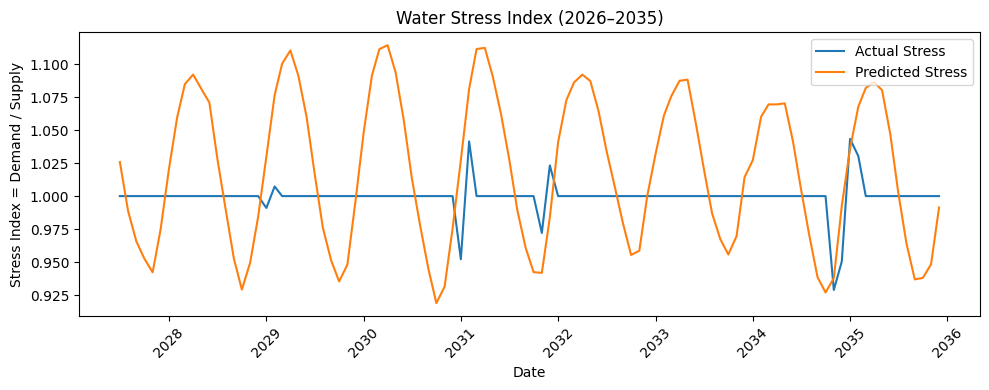

In [36]:
# Avoid division by zero
stress_pred = demand_pred / (supply_pred * 0.95 + 1e-6)
stress_true = demand_true / (supply_true + 1e-6)

stress_df = pd.DataFrame({
    "date": test_dates.values,
    "demand_pred_mcm": demand_pred,
    "supply_pred_mcm": supply_pred,
    "storage_pred_mcm": storage_pred,
    "stress_pred": stress_pred,
    "demand_true_mcm": demand_true,
    "supply_true_mcm": supply_true,
    "storage_true_mcm": storage_true,
    "stress_true": stress_true
})

print(stress_df.head())

plt.figure(figsize=(10,4))
plt.plot(test_dates, stress_true, label="Actual Stress")
plt.plot(test_dates, stress_pred, label="Predicted Stress")
plt.title("Water Stress Index (2026–2035)")
plt.xlabel("Date")
plt.ylabel("Stress Index = Demand / Supply")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 8.2 Water Stress Visualization

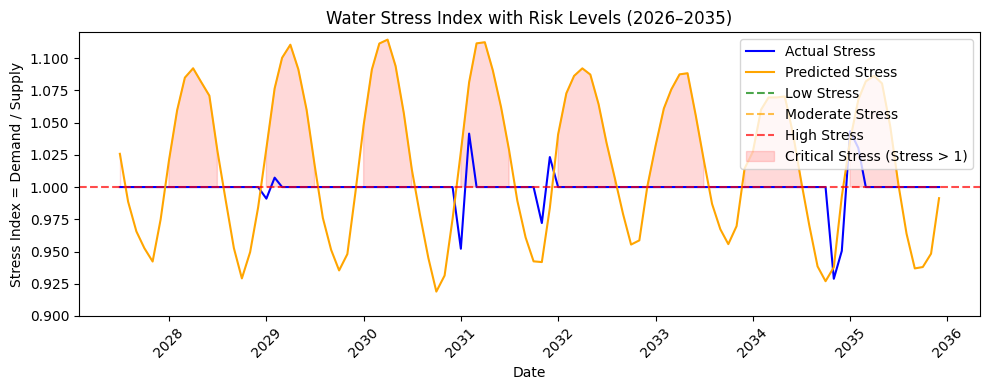

In [37]:
plt.figure(figsize=(10,4))

# Stress curves
plt.plot(test_dates, stress_true, label="Actual Stress", color="blue")
plt.plot(test_dates, stress_pred, label="Predicted Stress", color="orange")

# Thresholds
plt.axhline(0.5, linestyle="--", color="green", alpha=0.7, label="Low Stress")
plt.axhline(0.8, linestyle="--", color="orange", alpha=0.7, label="Moderate Stress")
plt.axhline(1.0, linestyle="--", color="red", alpha=0.7, label="High Stress")

# ✅ ADD HERE (highlight critical zones)
high_stress = stress_pred > 1.0

plt.fill_between(
    test_dates,
    1.0,
    stress_pred,
    where=high_stress,
    color="red",
    alpha=0.15,
    label="Critical Stress (Stress > 1)"
)
# Final formatting
plt.title("Water Stress Index with Risk Levels (2026–2035)")
plt.xlabel("Date")
plt.ylabel("Stress Index = Demand / Supply")
plt.legend(loc="upper right")
plt.xticks(rotation=45)
plt.ylim(0.9, 1.12)
plt.tight_layout()
plt.show()

---
##  9. Multi-Period Optimization — Model Predictive Control (MPC)
> Optimal water allocation across sectors: domestic, agricultural, industrial  
> Based on LSTM predictions fed into the MPC controller.

In [ ]:
# Predictive control parameters
HORIZON = 6
MIN_STORAGE = 20
WEIGHTS = np.array([10, 5, 1])   # domestic, agricultural, industrial

# Use ACTUAL values from the test set for closed-loop simulation
actual_dom = test_df['domestic_demand'].values[seq_length:]
actual_agr = test_df['agriculture_demand'].values[seq_length:]
actual_ind = test_df['industry_demand'].values[seq_length:]
actual_supply = test_df['supply_mcm'].values[seq_length:]
actual_evap = test_df['evaporation_mcm'].values[seq_length:]

# Forecasts used by MPC for planning
forecast_dom = domestic_pred
forecast_agr = agriculture_pred
forecast_ind = industry_pred
forecast_supply = supply_pred

# Initial storage
last_historical_storage = df.loc[
    df['date'] <= train_end, 'storage_reconstructed_mcm'
].iloc[-1]
stock = last_historical_storage

n_test = len(forecast_dom)

allocations = np.zeros((n_test, 3))
deficits = np.zeros((n_test, 3))
storage_sim = np.zeros(n_test)

for t in range(n_test):
    H = min(HORIZON, n_test - t)

    # ---------- Forecasts over the horizon ----------
    D_dom = forecast_dom[t:t+H]
    D_agr = forecast_agr[t:t+H]
    D_ind = forecast_ind[t:t+H]
    S_h   = forecast_supply[t:t+H]


    E_h   = actual_evap[t:t+H]

    n_vars = 3 * H + H

    # Objective: maximize weighted allocations = minimize negative weighted allocations
    c = np.zeros(n_vars)
    for i in range(H):
        c[3*i:3*i+3] = -WEIGHTS

    # ---------- Equality constraints: water balance ----------
    A_eq = []
    b_eq = []

    # Month 0
    A0 = np.zeros(n_vars)
    A0[0:3] = 1
    A0[3*H] = 1
    b0 = stock + S_h[0] - E_h[0]
    A_eq.append(A0)
    b_eq.append(b0)

    # Months 1..H-1
    for i in range(1, H):
        A = np.zeros(n_vars)
        A[3*i:3*i+3] = 1
        A[3*H + i] = 1
        A[3*H + i - 1] = -1
        b = S_h[i] - E_h[i]
        A_eq.append(A)
        b_eq.append(b)

    # ---------- Inequality constraints: storage >= MIN_STORAGE ----------
    A_ub = []
    b_ub = []

    for i in range(H):
        A = np.zeros(n_vars)
        A[3*H + i] = -1
        A_ub.append(A)
        b_ub.append(-MIN_STORAGE)

    # ---------- Bounds ----------
    bounds = []
    for i in range(H):
        bounds.append((0, D_dom[i]))
        bounds.append((0, D_agr[i]))
        bounds.append((0, D_ind[i]))

    for i in range(H):
        bounds.append((MIN_STORAGE, None))

    # ---------- Solve ----------
    res = linprog(
        c,
        A_eq=np.array(A_eq),
        b_eq=np.array(b_eq),
        A_ub=np.array(A_ub),
        b_ub=np.array(b_ub),
        bounds=bounds,
        method='highs'
    )

    if res.success:
        alloc_opt = res.x[:3]
    else:
        # fallback
        predicted_total_demand = D_dom[0] + D_agr[0] + D_ind[0]
        available = max(stock + S_h[0] - E_h[0] - MIN_STORAGE, 0)

        if predicted_total_demand > 0:
            ratio = min(available / predicted_total_demand, 1.0)
            alloc_opt = np.array([D_dom[0], D_agr[0], D_ind[0]]) * ratio
        else:
            alloc_opt = np.zeros(3)

    # ---------- Apply first control action to REAL system ----------
    # Allocation cannot exceed actual realized demand
    real_demands = np.array([actual_dom[t], actual_agr[t], actual_ind[t]])
    applied_alloc = np.minimum(alloc_opt, real_demands)

    allocations[t] = applied_alloc
    deficits[t] = real_demands - applied_alloc

    # Update storage with ACTUAL supply and ACTUAL evaporation
    stock = stock + actual_supply[t] - np.sum(applied_alloc) - actual_evap[t]
    stock = max(stock, MIN_STORAGE)

    storage_sim[t] = stock

## Visualization of Allocation and Storage Dynamics

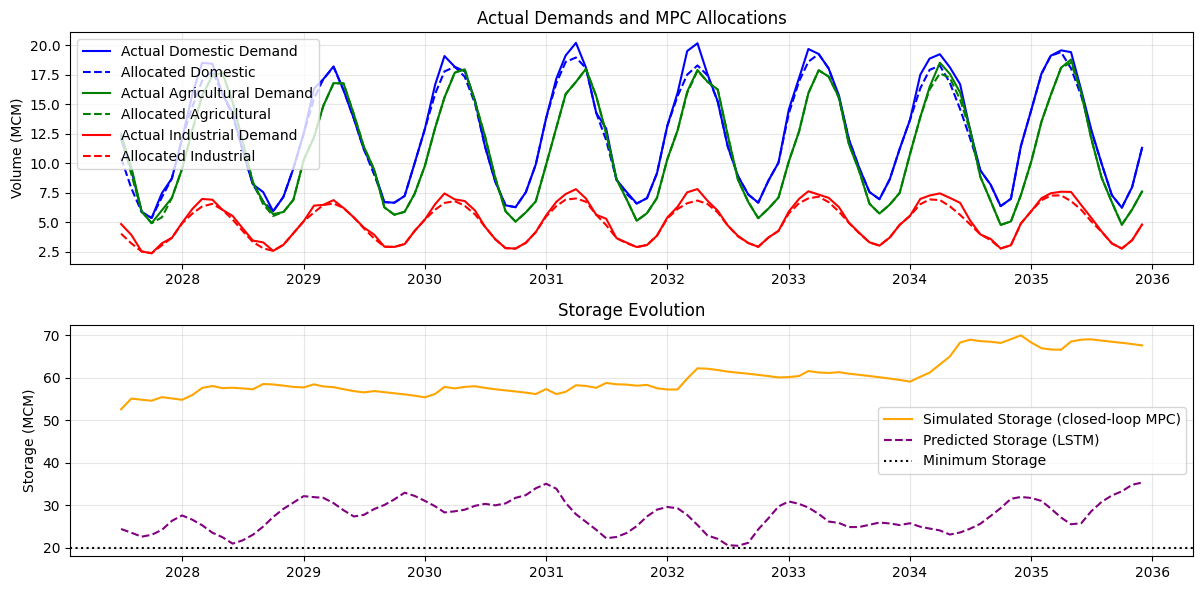

In [50]:
plt.figure(figsize=(12, 6))

plt.subplot(2,1,1)
plt.plot(test_dates, actual_dom, label='Actual Domestic Demand', color='blue')
plt.plot(test_dates, allocations[:,0], '--', label='Allocated Domestic', color='blue')

plt.plot(test_dates, actual_agr, label='Actual Agricultural Demand', color='green')
plt.plot(test_dates, allocations[:,1], '--', label='Allocated Agricultural', color='green')

plt.plot(test_dates, actual_ind, label='Actual Industrial Demand', color='red')
plt.plot(test_dates, allocations[:,2], '--', label='Allocated Industrial', color='red')

plt.legend()
plt.title('Actual Demands and MPC Allocations')
plt.ylabel('Volume (MCM)')
plt.grid(alpha=0.3)

plt.subplot(2,1,2)
plt.plot(test_dates, storage_sim, label='Simulated Storage (closed-loop MPC)', color='orange')
plt.plot(test_dates, storage_pred, '--', label='Predicted Storage (LSTM)', color='purple')
plt.axhline(y=MIN_STORAGE, color='k', linestyle=':', label='Minimum Storage')

plt.legend()
plt.title('Storage Evolution')
plt.ylabel('Storage (MCM)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Performance Metrics

In [51]:
total_deficit = np.sum(deficits, axis=0)
print("\n--- Deficit Summary ---")
print(f"Total Domestic Deficit    : {total_deficit[0]:.2f} MCM")
print(f"Total Agricultural Deficit: {total_deficit[1]:.2f} MCM")
print(f"Total Industrial Deficit  : {total_deficit[2]:.2f} MCM")

stress_months = np.sum(deficits > 1e-6, axis=0)
print(f"Domestic Stress Months    : {stress_months[0]}")
print(f"Agricultural Stress Months: {stress_months[1]}")
print(f"Industrial Stress Months  : {stress_months[2]}")


--- Deficit Summary ---
Total Domestic Deficit    : 30.77 MCM
Total Agricultural Deficit: 4.44 MCM
Total Industrial Deficit  : 20.78 MCM
Domestic Stress Months    : 41
Agricultural Stress Months: 14
Industrial Stress Months  : 59


## Results Interpretation

In [53]:
satisfaction_dom = 1 - total_deficit[0] / actual_dom.sum()
satisfaction_agr = 1 - total_deficit[1] / actual_agr.sum()
satisfaction_ind = 1 - total_deficit[2] / actual_ind.sum()

print("\n--- Satisfaction Rates ---")
print(f"Domestic    : {satisfaction_dom*100:.2f}%")
print(f"Agriculture : {satisfaction_agr*100:.2f}%")
print(f"Industrial  : {satisfaction_ind*100:.2f}%")


--- Satisfaction Rates ---
Domestic    : 97.60%
Agriculture : 99.61%
Industrial  : 95.99%


---
##  10. Conclusion
> This notebook presents a complete pipeline for water demand forecasting and optimization:
> - **LSTM** for predicting sectoral demands and reservoir storage
> - **MPC** for optimal allocation and deficit management
> - Forecast horizon: **2026–2035** | City: **Tangier, Morocco**